In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from Inject_Missing_Values import *
# Import your original OTImputer
from imputers import OTimputer
from Updated_OT import OTimputerDropOutNoise
from imputers_fullyActive import OTimputerFullyActive

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [3]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)

In [4]:
data = fetch_openml(name="wine", version=2, as_frame=True)
X_full = data.data.copy()

In [5]:
# Convert categorical to numerical codes
for col in X_full.select_dtypes(include=['category', 'object']).columns:
    X_full[col] = X_full[col].astype('category').cat.codes

In [6]:
scaler = MinMaxScaler() #data [0,1]
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

In [7]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [8]:
print(GroundTruth)

      Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
0    0.842105    0.191700  0.572193           0.257732   0.619565   
1    0.571053    0.205534  0.417112           0.030928   0.326087   
2    0.560526    0.320158  0.700535           0.412371   0.336957   
3    0.878947    0.239130  0.609626           0.319588   0.467391   
4    0.581579    0.365613  0.807487           0.536082   0.521739   
..        ...         ...       ...                ...        ...   
173  0.705263    0.970356  0.582888           0.510309   0.271739   
174  0.623684    0.626482  0.598930           0.639175   0.347826   
175  0.589474    0.699605  0.481283           0.484536   0.543478   
176  0.563158    0.365613  0.540107           0.484536   0.543478   
177  0.815789    0.664032  0.737968           0.716495   0.282609   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0         0.627586    0.573840              0.283019         0.593060   
1         0.575862    0.5

In [9]:
GroundTruth.nunique()

Alcohol                         126
Malic_acid                      133
Ash                              79
Alcalinity_of_ash                63
Magnesium                        53
Total_phenols                    97
Flavanoids                      132
Nonflavanoid_phenols             39
Proanthocyanins                 101
Color_intensity                 132
Hue                              78
OD280/OD315_of_diluted_wines    122
Proline                         121
dtype: int64

In [10]:
print("Alcohol",GroundTruth['Alcohol'].unique())
print("Malic_acid",GroundTruth['Malic_acid'].unique())
print("Ash",GroundTruth['Ash'].unique())
print("Alcalinity_of_ash",GroundTruth['Alcalinity_of_ash'].unique())
print("Magnesium",GroundTruth["Magnesium"].unique())
print("Total_phenols",GroundTruth['Total_phenols'].unique())
print("Flavanoids",GroundTruth['Flavanoids'].unique())
print("Nonflavanoid_phenols",GroundTruth['Nonflavanoid_phenols'].unique())
print("Proanthocyanins",GroundTruth['Proanthocyanins'].unique())
print("Color_intensity",GroundTruth['Color_intensity'].unique())
print("Hue",GroundTruth['Hue'].unique())
print("OD280/OD315_of_diluted_wines",GroundTruth['OD280/OD315_of_diluted_wines'].unique())
print("Proline",GroundTruth['Proline'].unique())

Alcohol [0.84210526 0.57105263 0.56052632 0.87894737 0.58157895 0.83421053
 0.88421053 0.79736842 1.         0.74473684 0.80789474 0.81315789
 0.71578947 0.97894737 0.88157895 0.68421053 0.86052632 0.73684211
 0.83157895 0.68684211 0.5        0.70526316 0.47894737 0.65
 0.53157895 0.62105263 0.59736842 0.74736842 0.78684211 0.71052632
 0.67105263 0.69736842 0.71842105 0.65263158 0.64473684 0.59210526
 0.53684211 0.83947368 0.66578947 0.62631579 0.75       0.83684211
 0.75526316 0.76578947 0.73421053 0.72105263 0.71315789 0.59473684
 0.70789474 0.35263158 0.34210526 0.42368421 0.69473684 0.3
 0.54736842 0.60789474 0.31052632 0.33157895 0.64736842 0.51578947
 0.24473684 0.16578947 0.52631579 0.21315789 0.43947368 0.25526316
 0.44473684 0.27631579 0.43157895 0.29736842 0.16315789 0.16052632
 0.43684211 0.15526316 0.37894737 0.20526316 0.41315789 0.34473684
 0.20789474 0.38947368 0.36578947 0.32105263 0.31315789 0.15263158
 0.11315789 0.39210526 0.19210526 0.1        0.         0.45789474


### MCAR

In [11]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing
budgets = [0.1, 0.2, 0.3]  # Query 10%, 25%, 50% of missing cells

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}


for missing_rate in missing_rates:
    generator_mcar = Inject_Missing_Values() #missing value generating
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()

    imputed_runs = []
    for i in range(4):
        print(f"Run {i+1}...")
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean = np.nanmean(imputed_stack, axis=0)
    imputed_std = np.nanstd(imputed_stack, axis=0)

    # Vanilla OTImputer (same for all budgets)
    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
        std_values = imputed_std[missing_mask.values]

        # Save Vanilla
        results_mcar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mcar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = imputed_mean.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mcar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mcar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mcar[metric]:
        for method in results_mcar[metric][budget]:
            values = results_mcar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mcar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mcar = df_results_mcar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mcar.columns.name = None
df_results_mcar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mcar.columns]
df_results_mcar.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Wine_results_mcar_metrics.csv", index=False)
    

Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%



Plotting results...


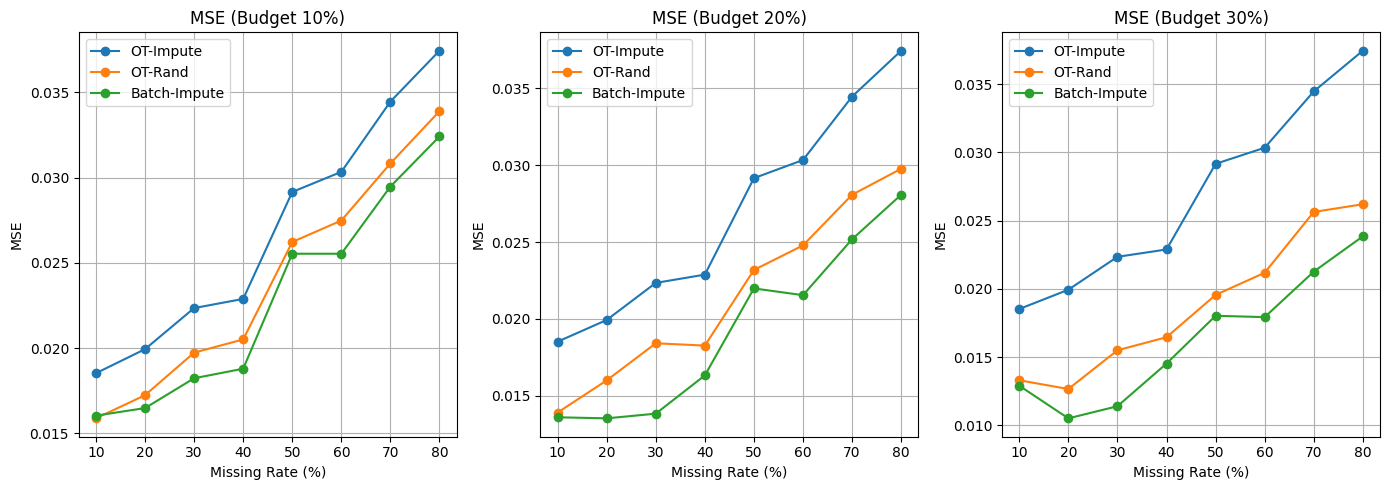

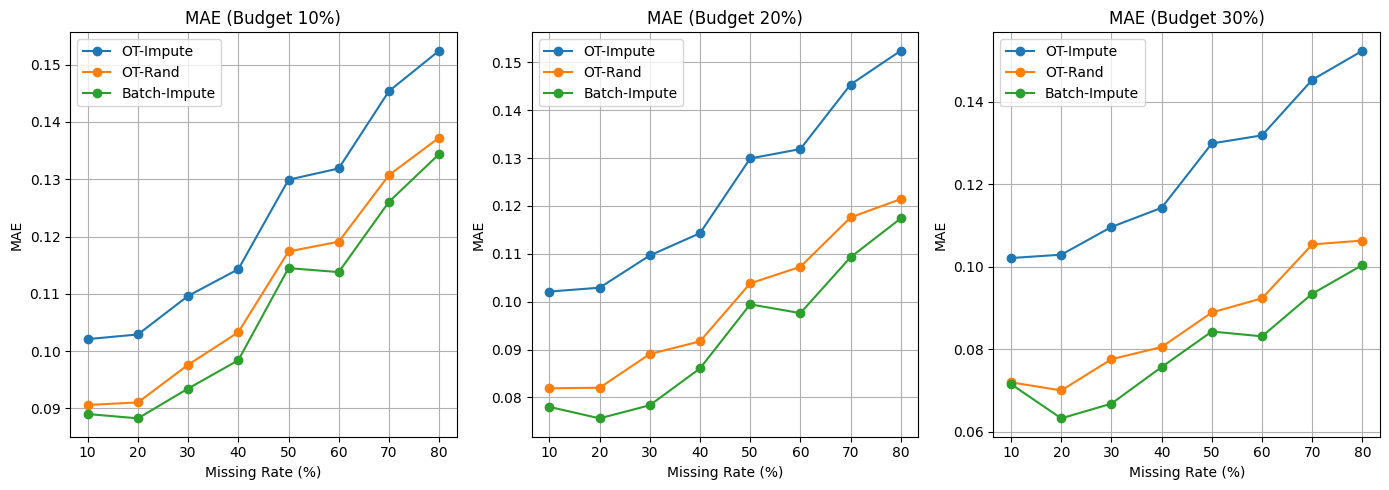

In [12]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

### MAR 

In [13]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
mean_flavanoids = GroundTruth["Flavanoids"].mean()
median_nonflavanoid = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()


dependencies_mar = {
    "Malic_acid": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Ash": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Alcalinity_of_ash": {
        "influencers": ["Ash"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] > mean_ash else 0.1
    },
    "Magnesium": {
        "influencers": ["Total_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] < median_phenols else 0.1
    },
    "Total_phenols": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "Flavanoids": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Nonflavanoid_phenols": {
        "influencers": ["Flavanoids"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] > mean_flavanoids else 0.1
    },
    "Proanthocyanins": {
        "influencers": ["Nonflavanoid_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] < median_nonflavanoid else 0.1
    },
    "Color_intensity": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Hue": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "influencers": ["Hue"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] < median_color else 0.1
    },
    "Proline": {
        "influencers": ["OD280/OD315_of_diluted_wines"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] > median_od280 else 0.1
    },
    "Alcohol": {
        "influencers": ["Proline"],  # Adding this as MAR (if you're okay with it having missingness)
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] > mean_proline else 0.1
    }
}



In [ ]:
results_mar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    total_missing_percentage_mar = miss_mar.isnull().sum().sum() / miss_mar.size * 100
    print(f"Total Missing Percentage MAR: {total_missing_percentage_mar:.2f}%")

    missing_percentage = (miss_mar.isnull().sum() / len(miss_mar)) * 100
    print(missing_percentage)

    missing_mask = miss_mar.isna()

    imputed_runs = []
    for i in range(4):
        print(f"Run {i+1}...")
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean = np.nanmean(imputed_stack, axis=0)
    imputed_std = np.nanstd(imputed_stack, axis=0)

    # Vanilla OTImputer (same for all budgets)
    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
        std_values = imputed_std[missing_mask.values]

        # Save Vanilla
        results_mar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = imputed_mean.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)

# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mcar[metric]:
        for method in results_mcar[metric][budget]:
            values = results_mcar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mar = df_results_mar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mar.columns.name = None
df_results_mar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mar.columns]
df_results_mar.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Wine_results_mar_metrics.csv", index=False)
    
    

Total Missing Percentage MAR: 9.98%
Alcohol                          8.426966
Malic_acid                      11.235955
Ash                             10.674157
Alcalinity_of_ash               11.235955
Magnesium                       12.921348
Total_phenols                   10.674157
Flavanoids                       3.932584
Nonflavanoid_phenols            12.359551
Proanthocyanins                 10.112360
Color_intensity                 11.797753
Hue                              8.988764
OD280/OD315_of_diluted_wines     6.741573
Proline                         10.674157
dtype: float64
Run 1...



Plotting results...


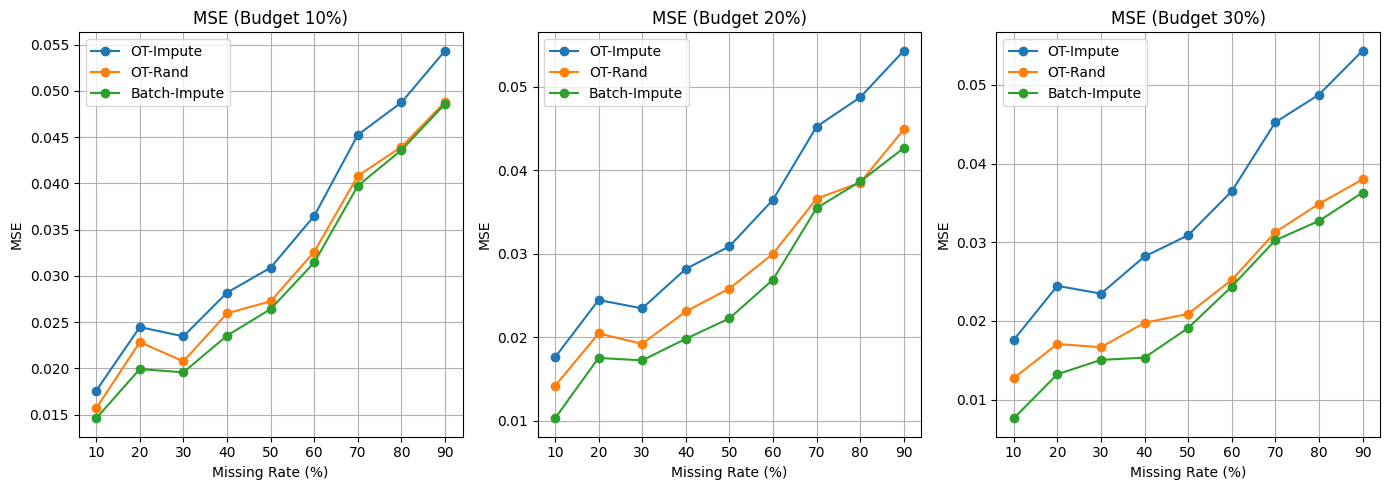

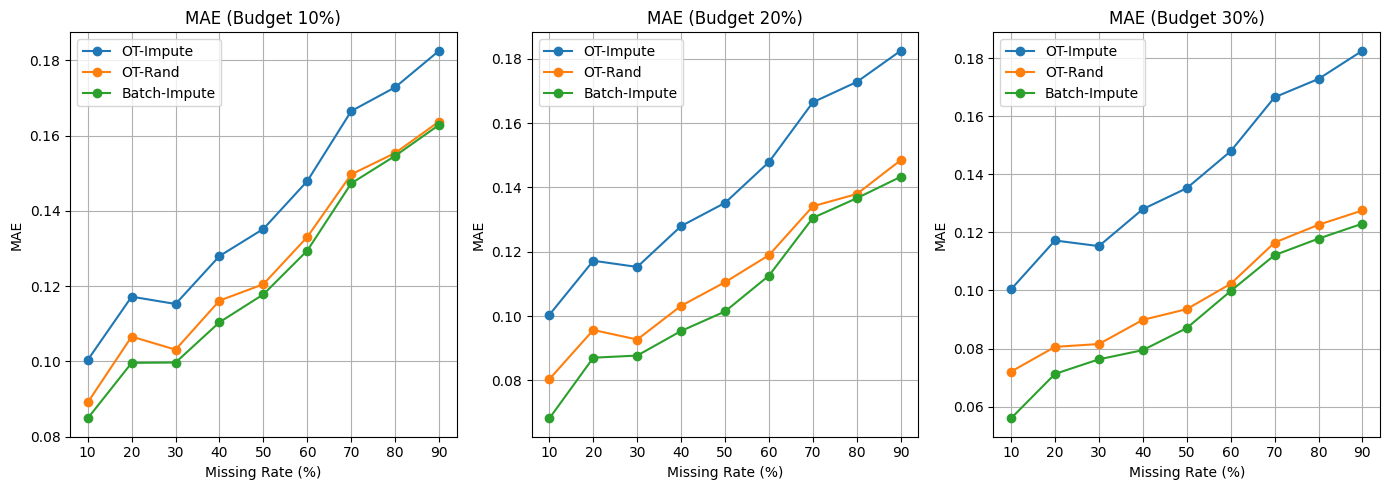

In [ ]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

### MNAR

In [ ]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
median_flav = GroundTruth["Flavanoids"].median()
median_nonflav = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()

dependencies_mnar = {
    "Alcohol": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] < mean_alcohol else 0.1
    },
    "Malic_acid": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] == median_malic else 0.1
    },
    "Ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] >= mean_ash else 0.1
    },
    "Alcalinity_of_ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcalinity_of_ash"] <= median_alcalinity else 0.1
    },
    "Magnesium": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Magnesium"] >= mean_magnesium else 0.1
    },
    "Total_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] <= median_phenols else 0.1
    },
    "Flavanoids": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] == median_flav else 0.1
    },
    "Nonflavanoid_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] <= median_nonflav else 0.1
    },
    "Proanthocyanins": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proanthocyanins"] < mean_proanthocyanins else 0.1
    },
    "Color_intensity": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] <= median_color else 0.1
    },
    "Hue": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] >= mean_hue else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] >= median_od280 else 0.1
    },
    "Proline": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] <= mean_proline else 0.1
    }
}


In [ ]:
results_mnar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()

    imputed_runs = []
    for i in range(4):
        print(f"Run {i+1}...")
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean = np.nanmean(imputed_stack, axis=0)
    imputed_std = np.nanstd(imputed_stack, axis=0)

    # Vanilla OTImputer (same for all budgets)
    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
        std_values = imputed_std[missing_mask.values]

        # Save Vanilla
        results_mnar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mnar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = imputed_mean.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mnar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mnar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)

#dataframe convertion
df_results_mnar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mnar = df_results_mnar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mnar.columns.name = None
df_results_mnar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mnar.columns]
df_results_mnar.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Wine_results_mnar_metrics.csv", index=False)
    

Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%



Plotting results...


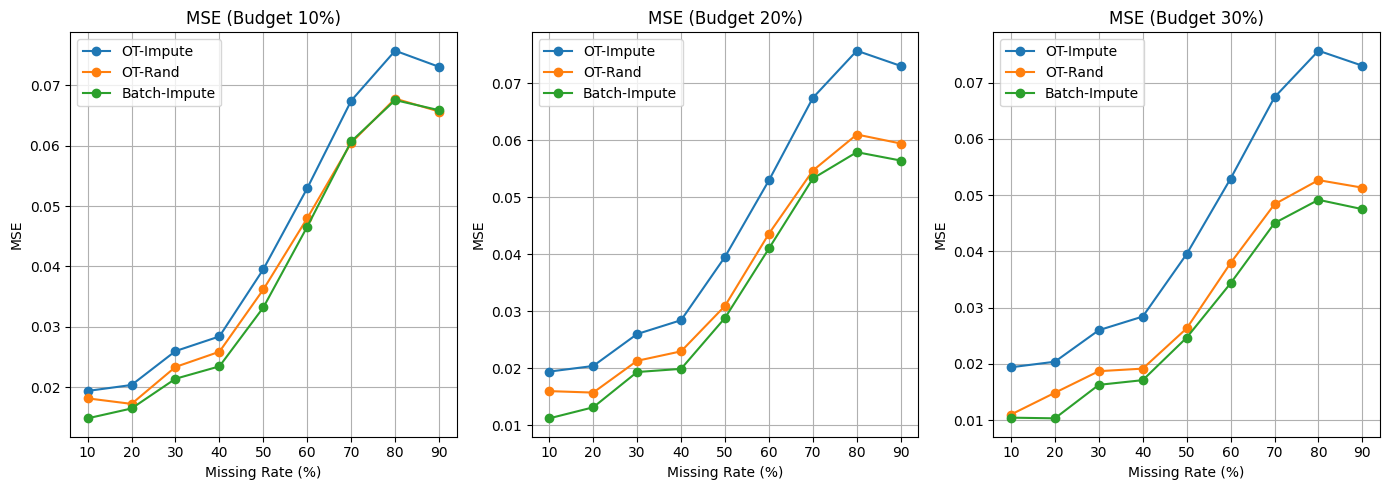

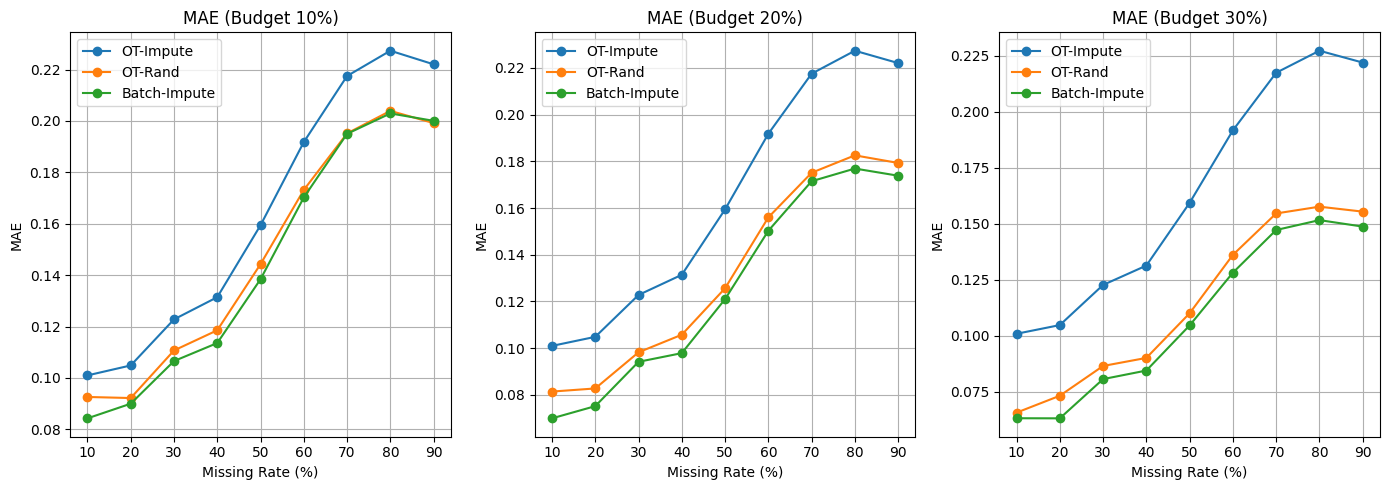

In [ ]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

⚠️ Skipped: MCAR, MSE, OT-Impute, budget 0.1
⚠️ Skipped: MCAR, MSE, OT-Rand, budget 0.1
⚠️ Skipped: MCAR, MSE, Batch-Impute, budget 0.1
⚠️ Skipped: MCAR, MSE, OT-Impute, budget 0.2
⚠️ Skipped: MCAR, MSE, OT-Rand, budget 0.2
⚠️ Skipped: MCAR, MSE, Batch-Impute, budget 0.2
⚠️ Skipped: MCAR, MSE, OT-Impute, budget 0.3
⚠️ Skipped: MCAR, MSE, OT-Rand, budget 0.3
⚠️ Skipped: MCAR, MSE, Batch-Impute, budget 0.3
⚠️ Skipped: MAR, MSE, OT-Impute, budget 0.1
⚠️ Skipped: MAR, MSE, OT-Rand, budget 0.1
⚠️ Skipped: MAR, MSE, Batch-Impute, budget 0.1
⚠️ Skipped: MAR, MSE, OT-Impute, budget 0.2
⚠️ Skipped: MAR, MSE, OT-Rand, budget 0.2
⚠️ Skipped: MAR, MSE, Batch-Impute, budget 0.2
⚠️ Skipped: MAR, MSE, OT-Impute, budget 0.3
⚠️ Skipped: MAR, MSE, OT-Rand, budget 0.3
⚠️ Skipped: MAR, MSE, Batch-Impute, budget 0.3
⚠️ Skipped: MNAR, MSE, OT-Impute, budget 0.1
⚠️ Skipped: MNAR, MSE, OT-Rand, budget 0.1
⚠️ Skipped: MNAR, MSE, Batch-Impute, budget 0.1
⚠️ Skipped: MNAR, MSE, OT-Impute, budget 0.2
⚠️ Skipped: 

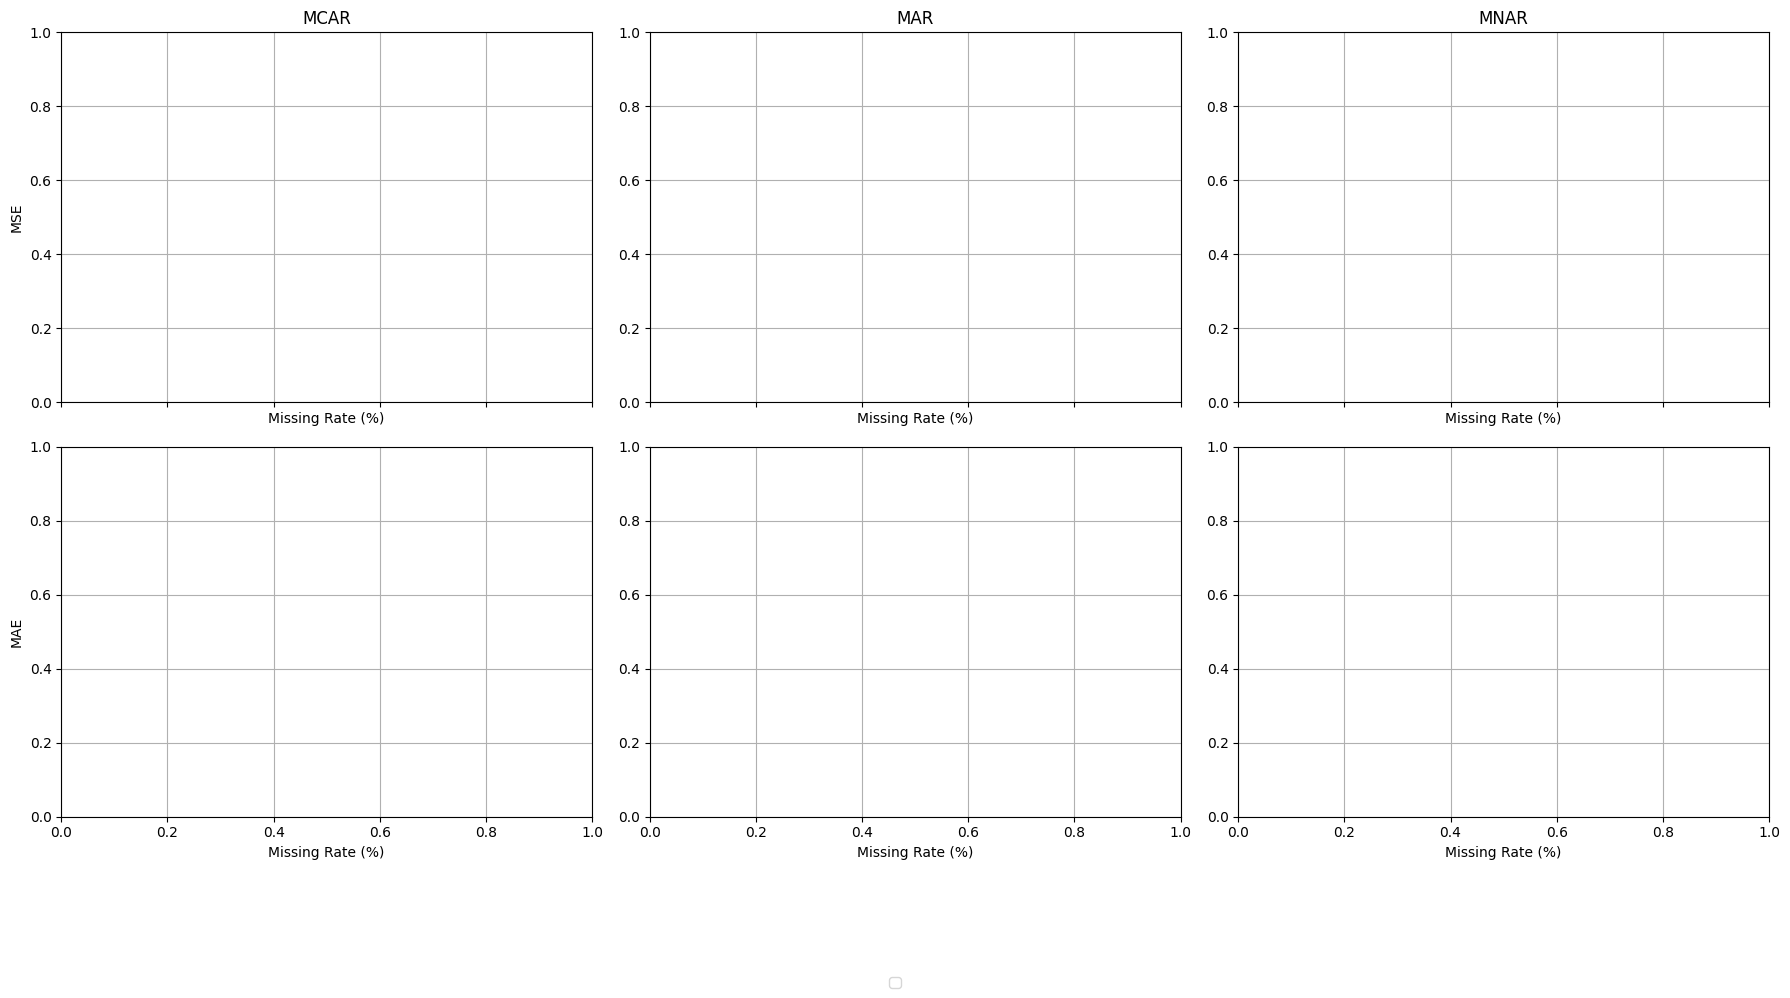

In [ ]:
import matplotlib.pyplot as plt

# === Data Setup (replace these with your real data) ===
# Each pattern result should follow this format:
# results_*[metric]["budget_fraction"]["method"] = list of values
pattern_data = {
    "MCAR": results_mcar,
    "MAR": results_mar,
    "MNAR": results_mnar
}

missing_patterns = ["MCAR", "MAR", "MNAR"]
budgets = [0.1, 0.2, 0.3]
methods = ["OT-Impute", "OT-Rand", "Batch-Impute"]
missing_rates = [10, 20, 30, 40, 50, 60, 70, 80]  # Adjust as needed

# === Style Settings ===
line_styles = {0.1: '-', 0.2: '--', 0.3: ':'}
markers = {"OT-Impute": 'o', "OT-Rand": 's', "Batch-Impute": '^'}
colors = {"OT-Impute": '#0072B2', "OT-Rand": '#E69F00', "Batch-Impute": '#009E73'}  # colorblind-friendly

# === Optional: std values for error bands ===
# Format: std_data[pattern][metric][budget][method] = list of stds
# Set to None if not using
std_data = None  # or load your std_data dictionary here

# === Plotting ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

metrics = ["MSE", "MAE"]

vanilla_labeled = False

for row_idx, metric in enumerate(metrics):
    for col_idx, pattern in enumerate(missing_patterns):
        ax = axes[row_idx, col_idx]
    
        results = pattern_data[pattern]

        for budget in budgets:
            for method in methods:
                plot_method = "Batch-Impute" if method == "Batch-Impute" else method
                values = results[metric][budget][plot_method]

                if len(values) != len(missing_rates):
                    print(f"⚠️ Skipped: {pattern}, {metric}, {method}, budget {budget}")
                    continue

                # Plot mean line
                if method == "OT-Impute":
                    label = "OT-Impute" if not vanilla_labeled else None
                    vanilla_labeled = True
                else:
                    label = f"{method} ({int(budget * 100)}% budget)"

                

                ax.plot(
                    missing_rates,
                    values,
                    linestyle=line_styles[budget],
                    marker=markers[method],
                    color=colors[method],
                    label=label
                )


                # Optional: Error bands
                if std_data:
                    std_vals = std_data[pattern][metric][budget][method]
                    if len(std_vals) == len(values):
                        lower = [v - s for v, s in zip(values, std_vals)]
                        upper = [v + s for v, s in zip(values, std_vals)]
                        ax.fill_between(missing_rates, lower, upper, color=colors[method], alpha=0.2)

        if row_idx == 0:
            ax.set_title(pattern)
        if col_idx == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("Missing Rate (%)")
        ax.grid(True)

# === Shared Legend ===
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', bbox_to_anchor=(0.5, -0.05))

# === Main Title & Layout ===

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_matrix.pdf", bbox_inches='tight')

plt.show()


## Comarision

MCAR Budget 0.1

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b01 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT-Impute": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT-Impute":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b01.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-Rand"] = round(mae_random, 4)
    all_results_comparision_mcar_b01.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-Rand",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["Batch-Impute"] = round(mae_active, 4)
    all_results_comparision_mcar_b01.append({
        "MissingRate(%)": missing_rate,
        "Method": "Batch-Impute",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b01 = pd.DataFrame(all_results_comparision_mcar_b01)
df_mae_summary_comparision_mcar_b01 = df_comparision_mcar_b01.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b01 .to_string(index=False))

df_mae_summary_comparision_mcar_b01.to_csv("C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Wine_comparison_mcar_budget01.csv", index=False)




=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1185
        MICE 0.1386
  OT-OneShot 0.1409
        Mean 0.1579
OT-RandomFix 0.1623
          OT 0.1816

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1352
        MICE 0.1400
  OT-OneShot 0.1421
        Mean 0.1575
OT-RandomFix 0.1634
          OT 0.1819

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1435
         KNN 0.1474
        Mean 0.1578
OT-RandomFix 0.1646
        MICE 0.1731
          OT 0.1830

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1451
         KNN 0.1538
        Mean 0.1580
        MICE 0.1619
OT-RandomFix 0.1655
          OT 0.1839

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1462
        Mean 0.1582
        MICE 0.1582
         KNN 0.1590
OT-RandomFix 0.1661
          OT 0.1852

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1468
        Mean 0.1579
         KNN 0.1580
        MICE 0.1586
OT-RandomFix 0.1668
          OT 0.1855

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1477
        MICE 0.1576
        Mean 0.1582
         KNN 0.1621
OT-RandomFix 0.1675
          OT 0.1860

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1487
        Mean 0.1579
        MICE 0.1594
         KNN 0.1623
OT-RandomFix 0.1681
          OT 0.1869

=== Missing Rate: 90% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.149

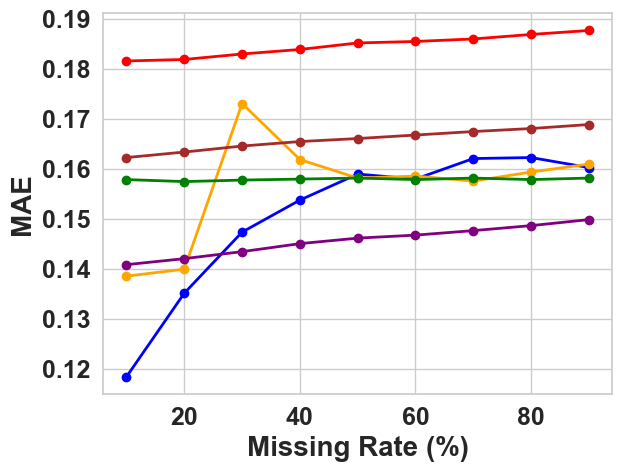

In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT-Impute": "red",
    "OT-Rand": "brown",
    "Batch-Impute": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b01.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b01["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b01[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_comparision_mcar_b01.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


MCAR Budget 0.2

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.2
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b02 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT-Impute": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT-Impute":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b02.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-Rand"] = round(mae_random, 4)
    all_results_comparision_mcar_b02.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-Rand",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["Batch-Impute"] = round(mae_active, 4)
    all_results_comparision_mcar_b02.append({
        "MissingRate(%)": missing_rate,
        "Method": "Batch-Impute",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b02 = pd.DataFrame(all_results_comparision_mcar_b02)
df_mae_summary_comparision_mcar_b02 = df_comparision_mcar_b02.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b02 .to_string(index=False))
df_mae_summary_comparision_mcar_b02.to_csv("C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Wine_mae_comparison_mcar_budget02.csv", index=False)




=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1186
  OT-OneShot 0.1226
        MICE 0.1391
OT-RandomFix 0.1459
        Mean 0.1581
          OT 0.1821

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1234
         KNN 0.1371
        MICE 0.1405
OT-RandomFix 0.1460
        Mean 0.1577
          OT 0.1824

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1253
         KNN 0.1460
OT-RandomFix 0.1461
        Mean 0.1578
        MICE 0.1722
          OT 0.1834

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1268
OT-RandomFix 0.1473
         KNN 0.1541
        Mean 0.1582
        MICE 0.1669
          OT 0.1843

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1279
OT-RandomFix 0.1475
         KNN 0.1572
        Mean 0.1578
        MICE 0.1588
          OT 0.1847

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1290
OT-RandomFix 0.1484
        Mean 0.1577
         KNN 0.1587
        MICE 0.1593
          OT 0.1854

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1299
OT-RandomFix 0.1487
        MICE 0.1569
        Mean 0.1575
         KNN 0.1578
          OT 0.1861

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.131

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT-Impute": "red",
    "OT-RandomFix": "brown",
    "OT-OneShot": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b02.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b02["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b02[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_comparision_mcar_b02.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


MCAR Budget 0.3

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.3
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b03 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT-Impute": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT-Impute":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b03.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-Rand"] = round(mae_random, 4)
    all_results_comparision_mcar_b03.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-Rand",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["Batch-Impute"] = round(mae_active, 4)
    all_results_comparision_mcar_b03.append({
        "MissingRate(%)": missing_rate,
        "Method": "Batch-Impute",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b03 = pd.DataFrame(all_results_comparision_mcar_b03)
df_mae_summary_comparision_mcar_b03 = df_comparision_mcar_b03.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b03 .to_string(index=False))
df_mae_summary_comparision_mcar_b03.to_csv("C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Wine_mae_comparison_mcar_budget03.csv", index=False)



In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT-Impute": "red",
    "OT-Rand": "brown",
    "Batch-Impute": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b03.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b03["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b03[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_comparision_mcar_b03.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


## Optimization

MCAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


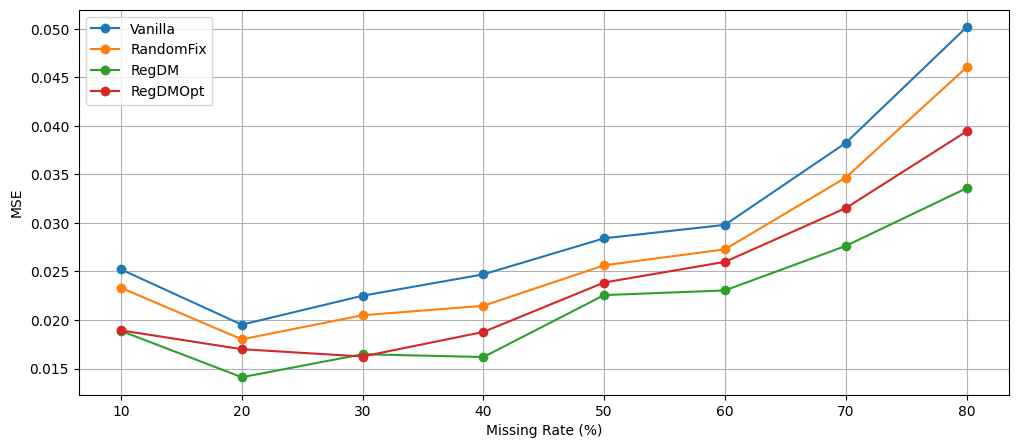

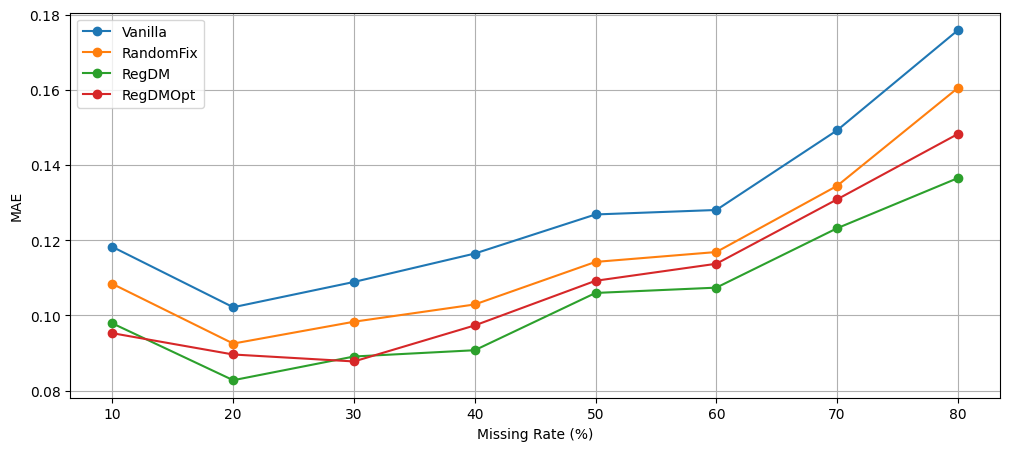

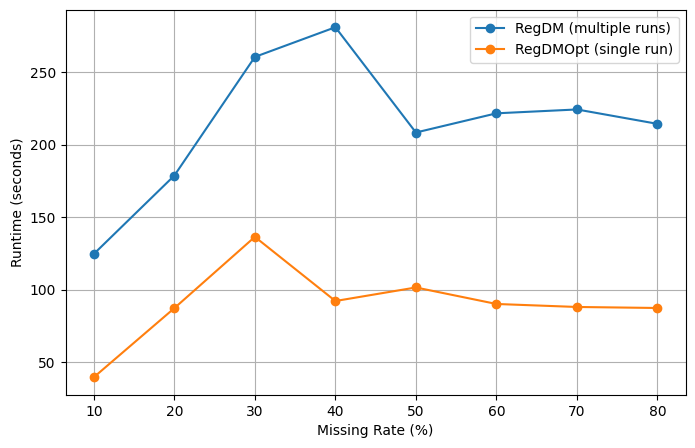

In [58]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mcar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mcar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=500,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["RegDMOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MCAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MCAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MCAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



In [82]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [ 0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]


results_mcar_opt_dropuOut = {d: [] for d in dropOutNoises}
n_runs = 10  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mcar = Inject_Missing_Values()
        miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
        missing_mask = miss_mcar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mcar_opt_dropuOut[dropOutNoise].append(mae)



=== Dropout Noise: 0 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.01 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Nois

MAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


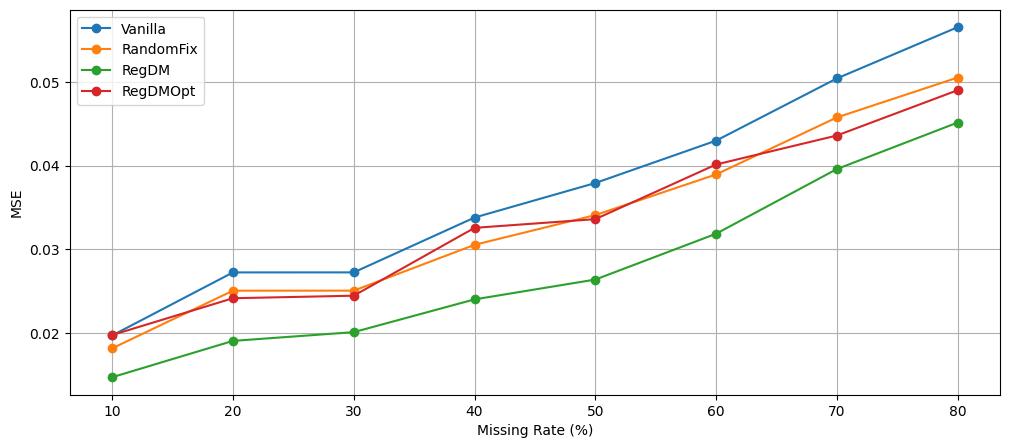

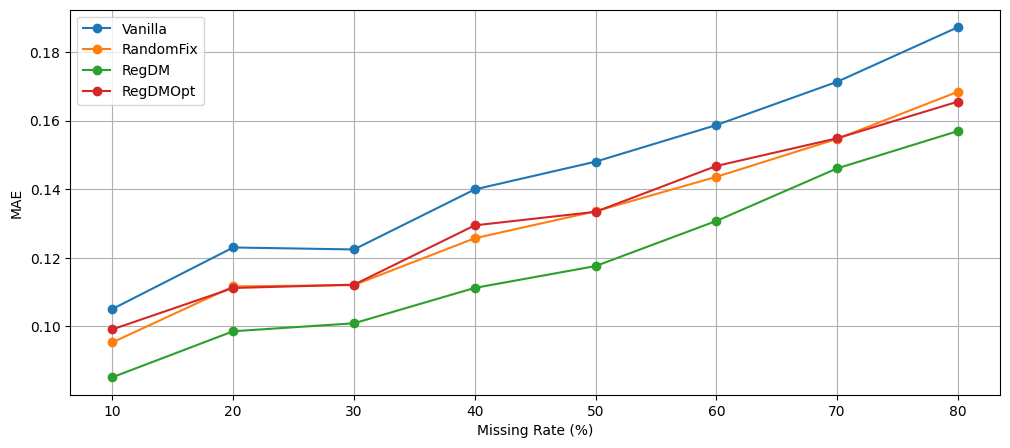

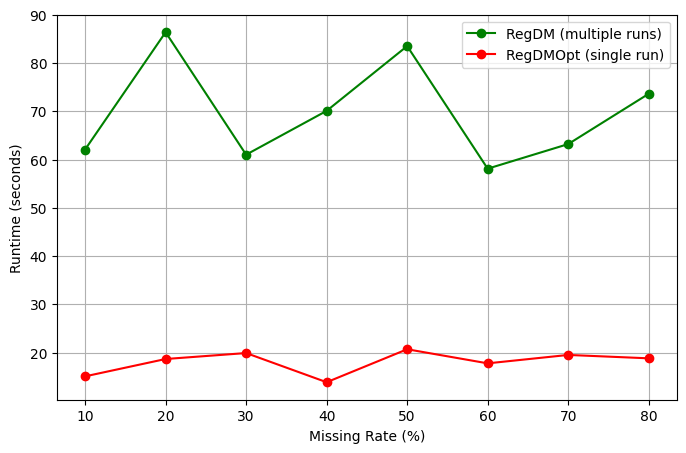

In [59]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    missing_mask = miss_mar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.001  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mar_opt["Time"]["RegDMOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()

plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o',color = 'red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



MNAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


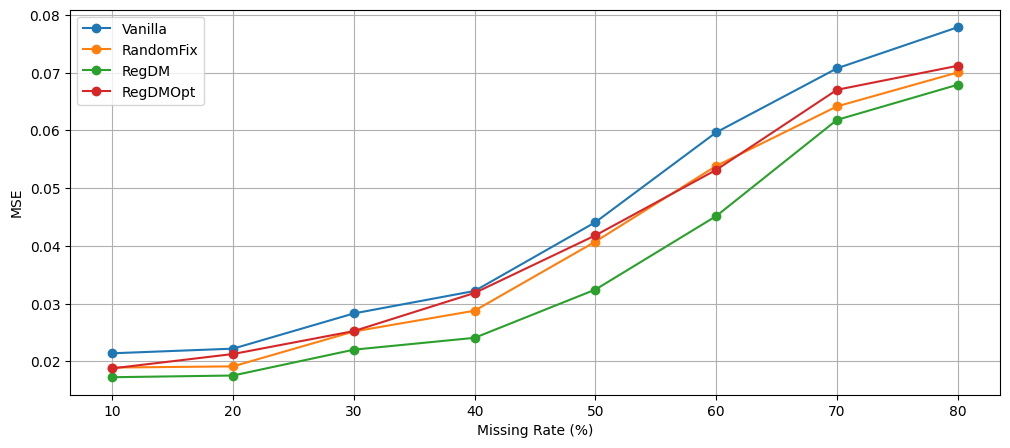

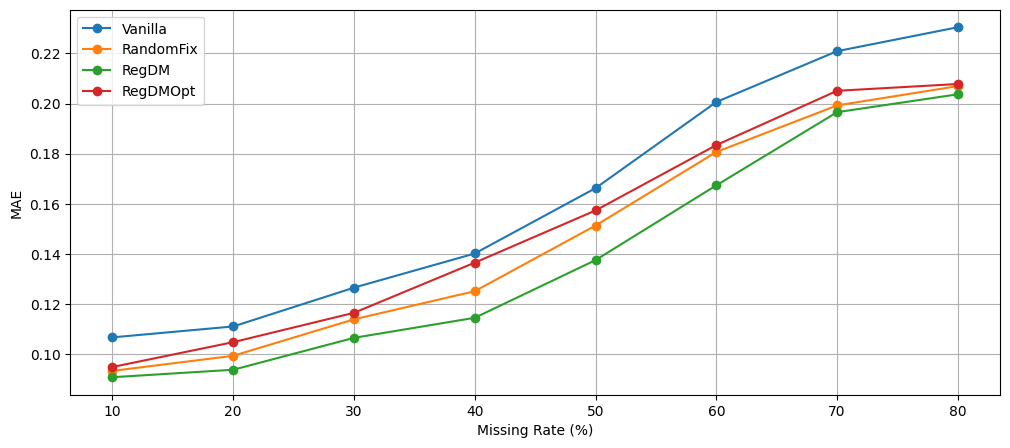

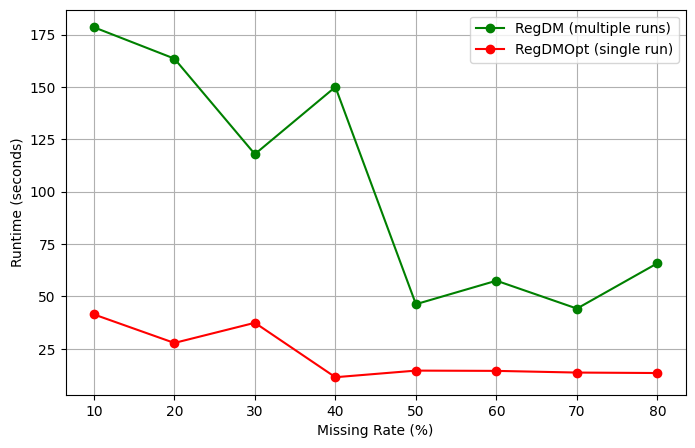

In [62]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mnar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mnar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mnar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mnar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mnar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mnar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mnar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mnar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.001  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mnar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mnar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mnar_opt["Time"]["RegDMOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mnar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MNAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mnar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MNAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mnar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mnar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o',color = 'red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Wine_MNAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



## Fully Active

MCAR

In [66]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X,missing_rate=30)
mask = X_missing.isna()

results_fullyActive_mcar = []
max_k = 4
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mcar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar= pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 694
    X_std (max value): 0.258657192073209
    Avg Std of Queried Cells: 0.1360
    Intermediate MAE after iteration 1: 0.1075
  Final MAE: 0.1075, Time: 13.57s, Unique Queried: 69, Avg Std: 0.1360

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 694
    X_std (max value): 0.260134860184945
    Avg Std of Queried Cells: 0.1651
    Intermediate MAE after iteration 1: 0.1104
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elemen

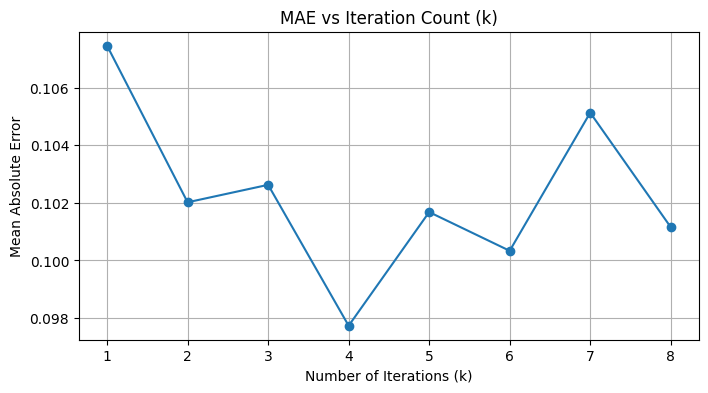

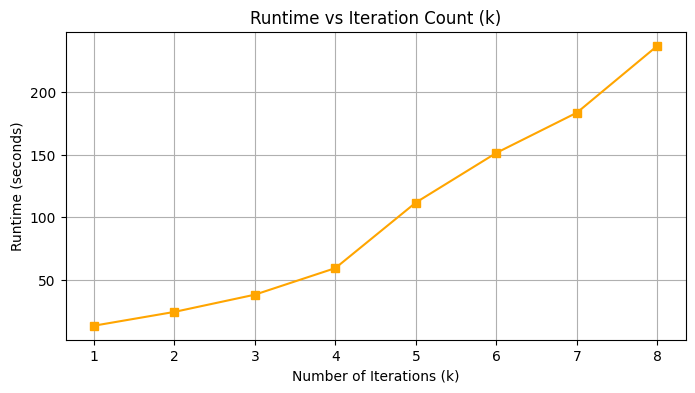

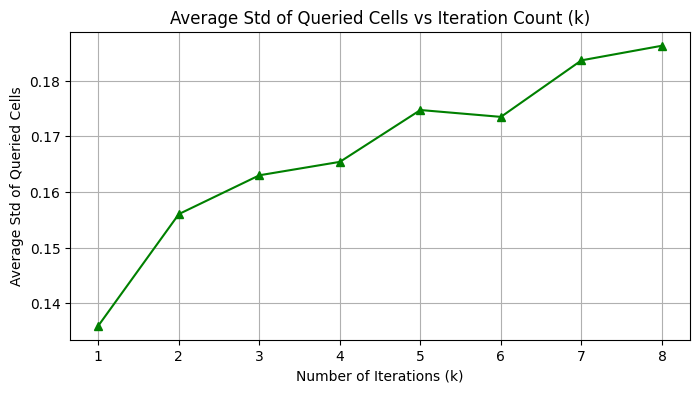

In [67]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MAR

In [68]:
generator_mar = Inject_Missing_Values()
X_missing, index_mar = generator_mar.MAR(X,missing_rate=30, dependencies = dependencies_mar)
mask = X_missing.isna()

results_fullyActive_mar = []
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 694
    X_std (max value): 0.19310389219998986
    Avg Std of Queried Cells: 0.1262
    Intermediate MAE after iteration 1: 0.1134
  Final MAE: 0.1134, Time: 25.57s, Unique Queried: 69, Avg Std: 0.1262

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 694
    X_std (max value): 0.2096284297645115
    Avg Std of Queried Cells: 0.1457
    Intermediate MAE after iteration 1: 0.1198
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero ele

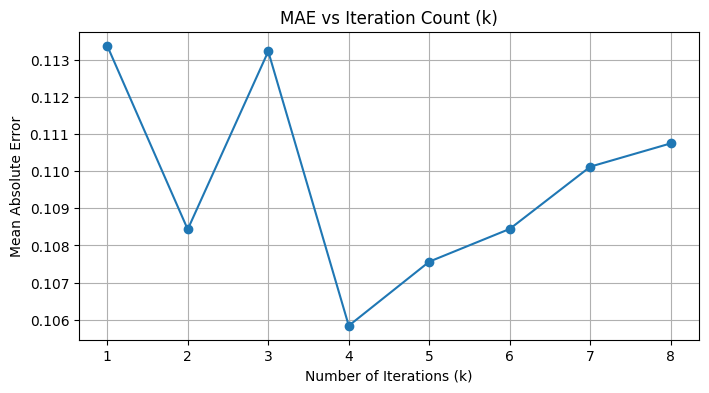

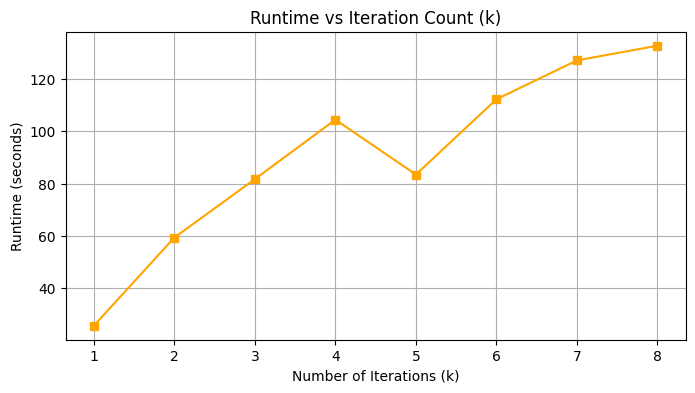

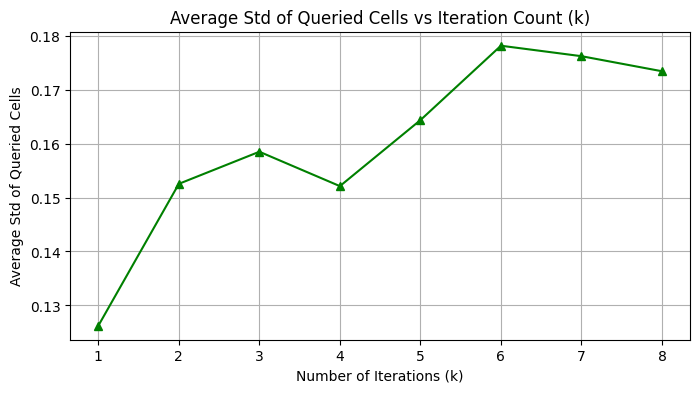

In [69]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MNAR

In [70]:
generator_mnar = Inject_Missing_Values()
X_missing, index_mnar = generator_mnar.MAR(X,missing_rate=30, dependencies = dependencies_mnar)
mask = X_missing.isna()

results_fullyActive_mnar = []
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mnar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 694
    X_std (max value): 0.23080847885045966
    Avg Std of Queried Cells: 0.1296
    Intermediate MAE after iteration 1: 0.1168
  Final MAE: 0.1168, Time: 17.91s, Unique Queried: 69, Avg Std: 0.1296

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 694
    X_std (max value): 0.1838836234314523
    Avg Std of Queried Cells: 0.1427
    Intermediate MAE after iteration 1: 0.1255
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero ele

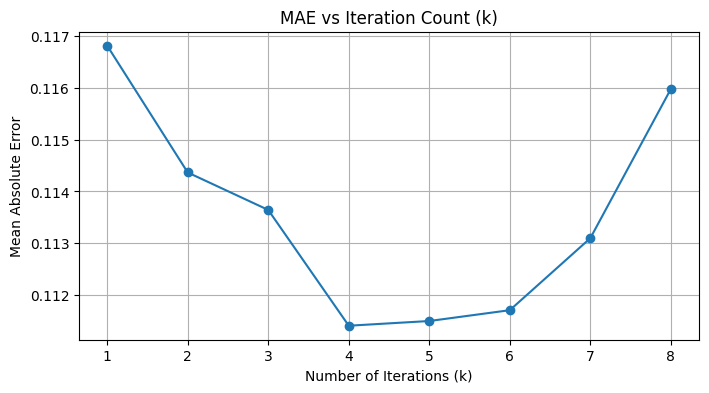

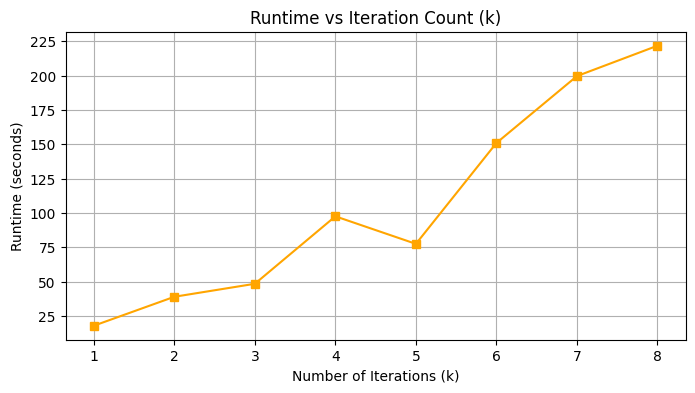

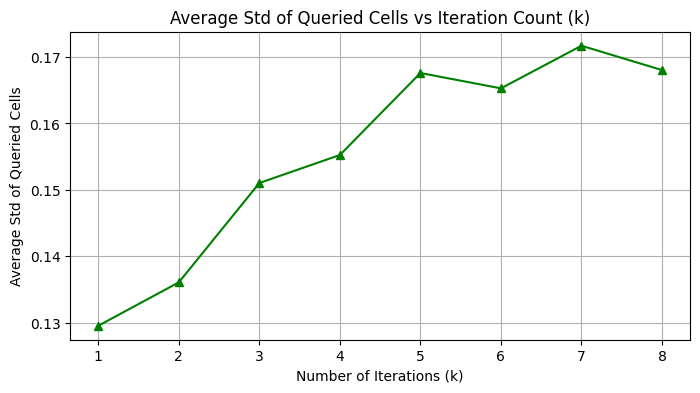

In [71]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()